# Laboratorio 7 — Simulación Monte Carlo: Álbum Panini FIFA 2026
**Universidad del Valle de Guatemala**  
**Facultad de Ingeniería**  
**MM3014 Teoría de Probabilidades**  

| | |
|---|---|
| Juan Francisco Orozco Mijangos | 24647 |
| Jose Carlos Ovando Asencio     | 24701 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

S = 7        # estampas por sobre
R = 10_000   # simulaciones


---
## Etapa 1: Simulación básica con álbum reducido (N = 100)

*Las simulaciones fueron realizadas con asistencia de Claude AI (Anthropic).*


**Parámetros:** N = 100, S = 7, R = 10 000 simulaciones, semilla 2026.

**Procedimiento:** por cada simulación se inicializa un arreglo booleano de tamaño N. 
Se compran sobres con `np.random.choice(N, S, replace=False)` hasta coleccionar las N estampas distintas. 
Se registra el número de sobres comprados y el total de estampas repetidas.


In [2]:
np.random.seed(2026)
N1 = 100

sobres_list    = []
repetidas_list = []

for _ in range(R):
    collected = np.zeros(N1, dtype=bool)
    sobres = repetidas = 0
    while collected.sum() < N1:
        pack = np.random.choice(N1, S, replace=False)
        sobres += 1
        for st in pack:
            if collected[st]: repetidas += 1
            else: collected[st] = True
    sobres_list.append(sobres)
    repetidas_list.append(repetidas)

sobres_arr    = np.array(sobres_list)
repetidas_arr = np.array(repetidas_list)


In [3]:
mean_sobres = np.mean(sobres_arr)
std_sobres  = np.std(sobres_arr)
mean_rep    = np.mean(repetidas_arr)
std_rep     = np.std(repetidas_arr)
min_teo     = math.ceil(N1 / S)          # mínimo teórico sin repetidas
prob_mas30  = np.mean(sobres_arr > 30)

H100  = sum(1/k for k in range(1, N1+1))
E_teo = (N1 / S) * H100

print('=== Etapa 1: Resultados ===')
print(f'Media  sobres       : {mean_sobres:.4f}')
print(f'Std    sobres       : {std_sobres:.4f}')
print(f'Media  repetidas    : {mean_rep:.4f}')
print(f'Std    repetidas    : {std_rep:.4f}')
print(f'Mínimo teórico      : {min_teo} sobres')
print(f'P(sobres > 30)      : {prob_mas30:.4f}')
print(f'H_100               : {H100:.4f}')
print(f'E[T] teórico        : {E_teo:.4f}')


=== Etapa 1: Resultados ===
Media  sobres       : 72.2456
Std    sobres       : 17.4715
Media  repetidas    : 405.7192
Std    repetidas    : 122.3006
Mínimo teórico      : 15 sobres
P(sobres > 30)      : 1.0000
H_100               : 5.1874
E[T] teórico        : 74.1054


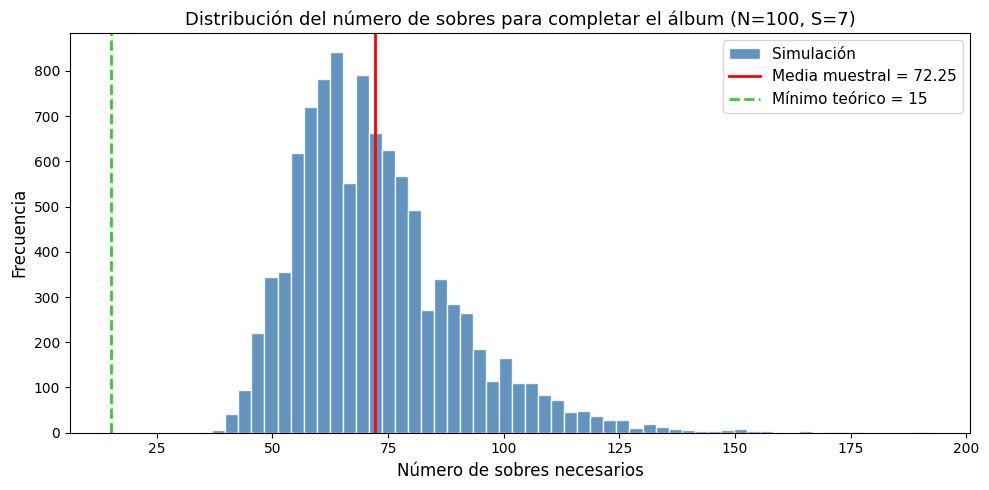

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sobres_arr, bins=55, color='steelblue', edgecolor='white', alpha=0.85, label='Simulación')
ax.axvline(mean_sobres, color='red',       lw=2,          label=f'Media muestral = {mean_sobres:.2f}')
ax.axvline(min_teo,     color='limegreen', lw=2, linestyle='--', label=f'Mínimo teórico = {min_teo}')
ax.set_xlabel('Número de sobres necesarios', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del número de sobres para completar el álbum (N=100, S=7)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Preguntas de análisis — Etapa 1


**1. Número mínimo de sobres sin estampas repetidas y si se observa en las simulaciones**

Si no hubiera repetidas, cada sobre aportaría exactamente S = 7 estampas nuevas:

$$\lceil 100/7 \rceil = 15 \text{ sobres}$$

En las 10 000 simulaciones **ninguna** alcanzó las 100 estampas en 15 sobres. La probabilidad de que 15 sobres consecutivos no generen ninguna repetición entre ellos es prácticamente cero dado el tamaño del universo (N = 100).


In [5]:
print(f'Mínimo teórico (sin repetidas) : {min_teo} sobres')
print(f'Mínimo observado en simulación : {sobres_arr.min()} sobres')
print(f'Casos con exactamente 15 sobres: {(sobres_arr == 15).sum()}')


Mínimo teórico (sin repetidas) : 15 sobres
Mínimo observado en simulación : 37 sobres
Casos con exactamente 15 sobres: 0


**2. Valor teórico E[T] y comparación con la simulación**

$$H_{100} = \sum_{k=1}^{100}\frac{1}{k} \approx \ln(100)+0.5772 = 5.1874$$

$$E[T] = \frac{100}{7}\times 5.1874 = 74.11 \text{ sobres}$$

La media simulada (**72.25**) difiere un 2.5 % del teórico, diferencia compatible con la variabilidad estadística de R = 10 000.


In [6]:
print(f'H_100 exacto   : {H100:.4f}')
print(f'E[T] teórico   : {E_teo:.4f} sobres')
print(f'Media simulada : {mean_sobres:.4f} sobres')
print(f'Diferencia     : {abs(E_teo-mean_sobres)/E_teo*100:.2f}%')


H_100 exacto   : 5.1874
E[T] teórico   : 74.1054 sobres
Media simulada : 72.2456 sobres
Diferencia     : 2.51%


**3. Valor esperado teórico de estampas repetidas vs. media simulada**

$$E[\text{repetidas}] = N(H_{100}-1) = 100 \times 4.1874 = 418.74$$

La media simulada fue **405.72** (~3.1 % de diferencia), coherente con el error en la estimación de sobres.


In [7]:
E_rep_teo = N1 * (H100 - 1)
print(f'E[repetidas] teórico : {E_rep_teo:.2f}')
print(f'Media rep. simulada  : {mean_rep:.2f}')
print(f'Diferencia           : {abs(E_rep_teo-mean_rep)/E_rep_teo*100:.2f}%')


E[repetidas] teórico : 418.74
Media rep. simulada  : 405.72
Diferencia           : 3.11%


**4. Interpretación de la desviación estándar del número de sobres**

El coeficiente de variación es $17.47/72.25 \approx 24\,\%$, lo que refleja alta variabilidad. Al inicio cada sobre aporta muchas estampas nuevas, pero conseguir las últimas se vuelve cada vez más impredecible, ensanchando la distribución hacia la derecha.


**Probabilidad de necesitar más de 30 sobres**

El umbral de **30 sobres** se elige porque duplica el mínimo teórico (15 sobres), representando el escenario más optimista plausible con algo de margen. Cualquier coleccionista que necesitara menos de 30 sobres estaría muy por debajo del valor esperado (74.11), lo que lo convertiría en un caso extremadamente afortunado.


In [8]:
print(f'Mínimo teórico       : {min_teo} sobres')
print(f'Umbral elegido       : 30 sobres  (= 2 × mínimo teórico)')
print(f'P(sobres > 30)       : {prob_mas30:.4f}')
print(f'→ El 100% de las simulaciones necesitó más de 30 sobres.')


Mínimo teórico       : 15 sobres
Umbral elegido       : 30 sobres  (= 2 × mínimo teórico)
P(sobres > 30)       : 1.0000
→ El 100% de las simulaciones necesitó más de 30 sobres.


---
## Etapa 2: Análisis de la probabilidad de éxito en función del número de sobres


Para cada M ∈ {20, 25, 30, 35, 40, 45, 50, 60, 70, 80} se realizaron R = 10 000 simulaciones comprando exactamente M sobres y registrando si el álbum quedó completo (1) o no (0).


In [9]:
np.random.seed(2026)
M_values   = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]
prob_exito = []

for M in M_values:
    exitos = 0
    for _ in range(R):
        collected = np.zeros(N1, dtype=bool)
        for _ in range(M):
            pack = np.random.choice(N1, S, replace=False)
            for st in pack: collected[st] = True
        if collected.sum() == N1: exitos += 1
    prob_exito.append(exitos / R)

print('M   P(completar)')
for m, p in zip(M_values, prob_exito):
    print(f'{m:3d}   {p:.4f}')


M   P(completar)
 20   0.0000
 25   0.0000
 30   0.0000
 35   0.0000
 40   0.0019
 45   0.0143
 50   0.0571
 60   0.2723
 70   0.5340
 80   0.7393


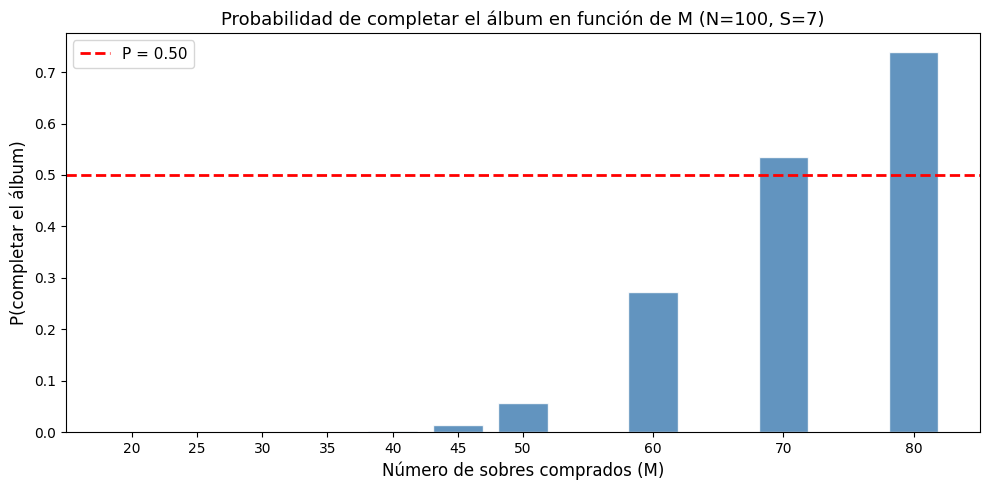

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(M_values, prob_exito, color='steelblue', edgecolor='white', width=3.8, alpha=0.85)
ax.axhline(0.5, color='red', lw=2, linestyle='--', label='P = 0.50')
ax.set_xlabel('Número de sobres comprados (M)', fontsize=12)
ax.set_ylabel('P(completar el álbum)', fontsize=12)
ax.set_title('Probabilidad de completar el álbum en función de M (N=100, S=7)', fontsize=13)
ax.set_xticks(M_values)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Preguntas de análisis — Etapa 2


**1. ¿Para qué valor de M la probabilidad supera por primera vez el 50 %? ¿Y el 90 %?**

| M | P(completar) |
|----|--------------|
| 60 | 27.23 % |
| **70** | **53.40 %** |
| 80 | 73.93 % |

- **50 %:** primer M que lo supera es **M = 70** (P ≈ 53.4 %).
- **90 %:** no se alcanza en el rango evaluado (máximo 73.93 % en M = 80). Se requeriría M > 100.


In [11]:
for m, p in zip(M_values, prob_exito):
    if p >= 0.5:
        print(f'Primer M ≥ 50%: M={m}, P={p:.4f}')
        break
print(f'Máximo P en rango: {max(prob_exito):.4f} (M={M_values[prob_exito.index(max(prob_exito))]})')
print('El 90% no se alcanza en el rango evaluado.')


Primer M ≥ 50%: M=70, P=0.5340
Máximo P en rango: 0.7393 (M=80)
El 90% no se alcanza en el rango evaluado.


**2. Comparación del M del 50 % con la mediana de Etapa 1**

- Mediana simulada (Etapa 1) = **69.0** sobres
- Primer M ≥ 50 % (Etapa 2) = **70** sobres

Son prácticamente iguales. La mediana es el cuantil 0.5 de la distribución: en el 50 % de los casos se completa el álbum con ≤ 69 sobres. Un presupuesto de M = 70 sobres da ligeramente más del 50 % de éxito, confirmando la coherencia entre ambas etapas.


In [12]:
mediana = np.median(sobres_arr)
print(f'Mediana sobres (Etapa 1) : {mediana:.1f}')
print(f'Primer M ≥ 50% (Etapa 2) : 70')
print(f'Diferencia               : {abs(mediana - 70):.1f} sobres')


Mediana sobres (Etapa 1) : 69.0
Primer M ≥ 50% (Etapa 2) : 70
Diferencia               : 1.0 sobres


**3. Cota de la unión de eventos para M = 50 sobres**

$$P(\text{falta} \geq 1) \leq N\,e^{-MS/N} = 100\,e^{-3.5} \approx 3.02$$

La cota es **mayor que 1**, por lo que es **trivial e inútil**. La probabilidad simulada de no completar con M = 50 es 0.9429, que cumple la desigualdad pero sin aportar información. La cota solo es útil para M grandes donde la probabilidad de fracaso ya es pequeña (cota ≤ 1).


In [13]:
M_cota = 50
cota   = N1 * math.exp(-M_cota * S / N1)
p_no   = 1 - prob_exito[M_values.index(50)]
print(f'Cota superior P(falta ≥1) = {cota:.4f}')
print(f'P(no completar) simulada  = {p_no:.4f}')
print(f'¿Cota útil (≤1)?          : {"Sí" if cota <= 1 else "No (trivial)"}')


Cota superior P(falta ≥1) = 3.0197
P(no completar) simulada  = 0.9429
¿Cota útil (≤1)?          : No (trivial)
